In [318]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mtick
import os

In [5]:
import sys
print(sys.executable)

c:\Users\maggi\anaconda3\envs\ghostjobs\python.exe


In [6]:
from jobspy import scrape_jobs

In [ ]:
# Charts
# - salary, education, seniority, company size histogram
# - descriptive statistics on variables
# - bar chart for categorical breakdowns (sectors/platforms)
# - number of job postings from each site and also distribution across sectors
# - salary non-disclosure rate by sector, platform, city
# - career page validation rate by sector, platform, city
# - description specificity by sector, platform, city histogram

In [ ]:
## File paths
current_dir = os.getcwd()
ma_path = "/Raw Data/MA/"
ny_path = "/Raw Data/NY/"
sector_paths = ["Finance & Insurance", "Professional, Scientific, & Technical", "Retail Trade"]

In [232]:
## Occupations Codes
# Finance and Insurance Sector
fi_occupation_codes = {
    "SB": "Securities, Commodities, and Financial Services",
    "IB": "Securities, Commodities, and Financial Services",
    "ISA": "Insurance Sales Agents",
    "FM": "Financial Managers",
    "IA": "Finance and Investment Analysts",
    "FA": "Finance and Investment Analysts",
    "PFA":"Personal Financial Advisors",
    "CSR": "Customer Service Representative"
}

# Professional, Scientific, and Technical Services Sector
pst_occupation_codes = {
    "ACCT": "Accountants and Auditors",
    "AUD": "Accountants and Auditors",
    "SWE": "Software Developers",
    "MC": "Management Analysts",
    "BA": "Management Analysts",
    "BC": "Management Analysts",
    "GM": "General and Operations Managers",
    "OM": "General and Operations Managers",
    "LAW": "Lawyers",
    "PLA": "Paralegals and Legal Assistants",
}

# Retail Trade Sector
rt_occupation_codes = {
    "RSP": "Retail Salespersons",
    "CASH": "Cashiers",
    "STK": "Stockers and Order Fillers",
    "SUP": "First-Line Supervisors of Retail Sales Workers",
    "DM": "First-Line Supervisors of Retail Sales Workers",
    "CSR": "Customer Service Representatives",
    "GM": "General and Operations Managers",
    "OM": "General and Operations Managers"
}

In [340]:
## Finance and Insurance Sector Merged Data for MA and NY
ma_fi_path = current_dir + ma_path + sector_paths[0] + "/"
ny_fi_path = current_dir + ny_path + sector_paths[0] + "/"

ma_finance_files = os.listdir(ma_fi_path)
ny_finance_files = os.listdir(ny_fi_path)

ma_fi_df = pd.DataFrame()
ny_fi_df = pd.DataFrame()

ma_fi_occ_count = {}
ny_fi_occ_count = {}
ma_fi_salary_disc = {"total": 0}
ny_fi_salary_disc = {"total": 0}
ma_fi_link_disc = {"total": 0}
ny_fi_link_disc = {"total": 0}

# merging data for all sector job postings based on state
for file in ma_finance_files:
    occ_code = file.split("-")[2]
    occupation = fi_occupation_codes.get(occ_code, "Unknown")
    data = pd.read_csv(ma_fi_path + "/" + file)
    if occupation in ma_fi_occ_count:
        ma_fi_occ_count[occupation] += len(data)
    else:
        ma_fi_occ_count[occupation] = len(data)
    ma_salary_df = data[["min_amount", "max_amount"]]
    ma_salary_disclosure_df = ma_salary_df.dropna()
    if occupation in ma_fi_salary_disc:
        ma_fi_salary_disc[occupation] += len(ma_salary_disclosure_df)
    else:
        ma_fi_salary_disc[occupation] = len(ma_salary_disclosure_df)
    ma_fi_salary_disc["total"] += len(ma_salary_disclosure_df)
    ma_fi_link_disc["total"] += len(data["job_url_direct"].dropna())
    ma_fi_df = pd.concat([ma_fi_df, data], ignore_index=True)

for file in ny_finance_files:
    occ_code = file.split("-")[2]
    occupation = fi_occupation_codes.get(occ_code, "Unknown")
    data = pd.read_csv(ny_fi_path + "/" + file)
    if occupation in ny_fi_occ_count:
        ny_fi_occ_count[occupation] += len(data)
    else:
        ny_fi_occ_count[occupation] = len(data)
    ny_salary_df = data[["min_amount", "max_amount"]]
    ny_salary_disclosure_df = ny_salary_df.dropna()
    if occupation in ny_fi_salary_disc:
        ny_fi_salary_disc[occupation] += len(ny_salary_disclosure_df)
    else:
        ny_fi_salary_disc[occupation] = len(ny_salary_disclosure_df)
    ny_fi_salary_disc["total"] += len(ny_salary_disclosure_df)
    ny_fi_link_disc["total"] += len(data["job_url_direct"].dropna())
    ny_fi_df = pd.concat([ny_fi_df, data], ignore_index=True)

ma_fi_df = ma_fi_df.drop(columns=['company_logo', 'skills', 'experience_range', 'company_rating', 'company_reviews_count', 'vacancy_count', 'work_from_home_type'])
ny_fi_df = ny_fi_df.drop(columns=['company_logo', 'skills', 'experience_range', 'company_rating', 'company_reviews_count', 'vacancy_count', 'work_from_home_type'])

In [212]:
print("MA FI LinkedIn: " + str(len(ma_fi_df[ma_fi_df["site"] == "linkedin"])))
print("MA FI Indeed: " + str(len(ma_fi_df[ma_fi_df["site"] == "indeed"])))
print("NY FI LinkedIn: " + str(len(ny_fi_df[ny_fi_df["site"] == "linkedin"])))
print("NY FI Indeed: " + str(len(ny_fi_df[ny_fi_df["site"] == "indeed"])))
print("MA FI Occupation Counts:" + str(ma_fi_occ_count))
print("NY FI Occupation Counts:" + str(ny_fi_occ_count))

MA FI LinkedIn: 117
MA FI Indeed: 26
NY FI LinkedIn: 206
NY FI Indeed: 229
MA FI Occupation Counts:{'Finance and Investment Analysts': 63, 'Financial Managers': 22, 'Securities, Commodities, and Financial Services': 27, 'Insurance Sales Agents': 18, 'Personal Financial Advisors': 13}
NY FI Occupation Counts:{'Customer Service Representative': 96, 'Finance and Investment Analysts': 152, 'Financial Managers': 74, 'Securities, Commodities, and Financial Services': 69, 'Personal Financial Advisors': 44}


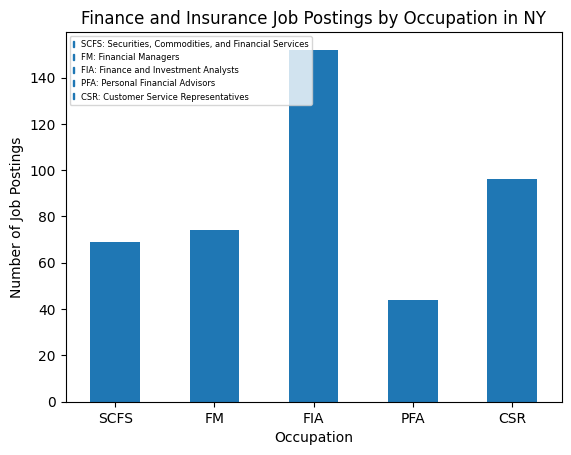

In [ ]:
# Finance and Insurance Sector Bar Chart for NY
fi_barchart = pd.DataFrame({
    'Occupation': [
        "SCFS",
        "FM",
        "FIA",
        "PFA",
        "CSR"
    ],
    'Job Postings': [
        ny_fi_occ_count.get("Securities, Commodities, and Financial Services", 0),
        ny_fi_occ_count.get("Financial Managers", 0),
        ny_fi_occ_count.get("Finance and Investment Analysts", 0),
        ny_fi_occ_count.get("Personal Financial Advisors", 0),
        ny_fi_occ_count.get("Customer Service Representative", 0)
    ]})

ax = fi_barchart.plot.bar(x='Occupation', y='Job Postings', rot=0)
plt.title("Finance and Insurance Job Postings by Occupation in NY")
plt.xlabel("Occupation")
plt.ylabel("Number of Job Postings")

# legend
legend_labels = [
    mpatches.Patch(color='tab:blue', label="SCFS: Securities, Commodities, and Financial Services"),
    mpatches.Patch(color='tab:blue', label="FM: Financial Managers"),
    mpatches.Patch(color='tab:blue', label="FIA: Finance and Investment Analysts"),
    mpatches.Patch(color='tab:blue', label="PFA: Personal Financial Advisors"),
    mpatches.Patch(color='tab:blue', label="CSR: Customer Service Representatives")
]
plt.legend(handles=legend_labels, loc='upper left', handlelength=0.1, fontsize=6)

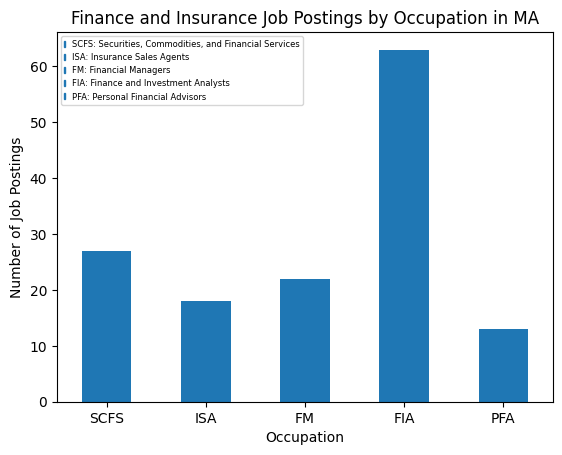

In [222]:
# Finance and Insurance Sector Bar Chart for MA
fi_barchart = pd.DataFrame({
    'Occupation': [
        "SCFS",
        "ISA",
        "FM",
        "FIA",
        "PFA"
    ],
    'Job Postings': [
        ma_fi_occ_count.get("Securities, Commodities, and Financial Services", 0),
        ma_fi_occ_count.get("Insurance Sales Agents", 0),
        ma_fi_occ_count.get("Financial Managers", 0),
        ma_fi_occ_count.get("Finance and Investment Analysts", 0),
        ma_fi_occ_count.get("Personal Financial Advisors", 0)
    ]})

ax = fi_barchart.plot.bar(x='Occupation', y='Job Postings', rot=0)
plt.title("Finance and Insurance Job Postings by Occupation in MA")
plt.xlabel("Occupation")
plt.ylabel("Number of Job Postings")

# legend
legend_labels = [
    mpatches.Patch(color='tab:blue', label="SCFS: Securities, Commodities, and Financial Services"),
    mpatches.Patch(color='tab:blue', label="ISA: Insurance Sales Agents"),
    mpatches.Patch(color='tab:blue', label="FM: Financial Managers"),
    mpatches.Patch(color='tab:blue', label="FIA: Finance and Investment Analysts"),
    mpatches.Patch(color='tab:blue', label="PFA: Personal Financial Advisors"),
]
plt.legend(handles=legend_labels, loc='upper left', handlelength=0.1, fontsize=6)

In [341]:
## Professional Scientific Technical Sector Merged Data for MA and NY
ma_pst_path = current_dir + ma_path + sector_paths[1] + "/"
ny_pst_path = current_dir + ny_path + sector_paths[1] + "/"

ma_pst_files = os.listdir(ma_pst_path)
ny_pst_files = os.listdir(ny_pst_path)

ma_pst_df = pd.DataFrame()
ny_pst_df = pd.DataFrame()

ma_pst_occ_count = {}
ny_pst_occ_count = {}
ma_pst_salary_disc = {"total": 0}
ny_pst_salary_disc = {"total": 0}
ma_pst_link_disc = {"total": 0}
ny_pst_link_disc = {"total": 0}

# merging data for all sector job postings based on state
for file in ma_pst_files:
    occ_code = file.split("-")[2]
    occupation = pst_occupation_codes.get(occ_code, "Unknown")
    data = pd.read_csv(ma_pst_path + "/" + file)
    if occupation in ma_pst_occ_count:
        ma_pst_occ_count[occupation] += len(data)
    else:
        ma_pst_occ_count[occupation] = len(data)
    ma_salary_df = data[["min_amount", "max_amount"]]
    ma_salary_disclosure_df = ma_salary_df.dropna()
    if occupation in ma_pst_salary_disc:
        ma_pst_salary_disc[occupation] += len(ma_salary_disclosure_df)
    else:
        ma_pst_salary_disc[occupation] = len(ma_salary_disclosure_df)
    ma_pst_salary_disc["total"] += len(ma_salary_disclosure_df)
    ma_pst_link_disc["total"] += len(data["job_url_direct"].dropna())
    ma_pst_df = pd.concat([ma_pst_df, data], ignore_index=True)

for file in ny_pst_files:
    occ_code = file.split("-")[2]
    occupation = pst_occupation_codes.get(occ_code, "Unknown")
    data = pd.read_csv(ny_pst_path + "/" + file)
    if occupation in ny_pst_occ_count:
        ny_pst_occ_count[occupation] += len(data)
    else:
        ny_pst_occ_count[occupation] = len(data)
    ny_salary_df = data[["min_amount", "max_amount"]]
    ny_salary_disclosure_df = ny_salary_df.dropna()
    if occupation in ny_pst_salary_disc:
        ny_pst_salary_disc[occupation] += len(ny_salary_disclosure_df)
    else:
        ny_pst_salary_disc[occupation] = len(ny_salary_disclosure_df)
    ny_pst_salary_disc["total"] += len(ny_salary_disclosure_df)
    ny_pst_link_disc["total"] += len(data["job_url_direct"].dropna())
    ny_pst_df = pd.concat([ny_pst_df, data], ignore_index=True)

ma_pst_df = ma_pst_df.drop(columns=['company_logo', 'skills', 'experience_range', 'company_rating', 'company_reviews_count', 'vacancy_count', 'work_from_home_type'])
ny_pst_df = ny_pst_df.drop(columns=['company_logo', 'skills', 'experience_range', 'company_rating', 'company_reviews_count', 'vacancy_count', 'work_from_home_type'])

In [226]:
print("MA PST Total: " + str(len(ma_pst_df)))
print("NY PST Total: " + str(len(ny_pst_df)))
print("MA PST LinkedIn: " + str(len(ma_pst_df[ma_pst_df["site"] == "linkedin"])))
print("MA PST Indeed: " + str(len(ma_pst_df[ma_pst_df["site"] == "indeed"])))
print("NY PST LinkedIn: " + str(len(ny_pst_df[ny_pst_df["site"] == "linkedin"])))
print("NY PST Indeed: " + str(len(ny_pst_df[ny_pst_df["site"] == "indeed"])))
print("MA PST Occupation Counts:" + str(ma_pst_occ_count))
print("NY PST Occupation Counts:" + str(ny_pst_occ_count))

MA PST Total: 405
NY PST Total: 519
MA PST LinkedIn: 290
MA PST Indeed: 115
NY PST LinkedIn: 324
NY PST Indeed: 195
MA PST Occupation Counts:{'Accountants and Auditors': 51, 'Management Analysts': 120, 'General and Operations Managers': 140, 'Lawyers': 22, 'Software Developers': 72}
NY PST Occupation Counts:{'Accountants and Auditors': 80, 'Management Analysts': 245, 'Lawyers': 58, 'Paralegals and Legal Assistants': 30, 'Software Developers': 106}


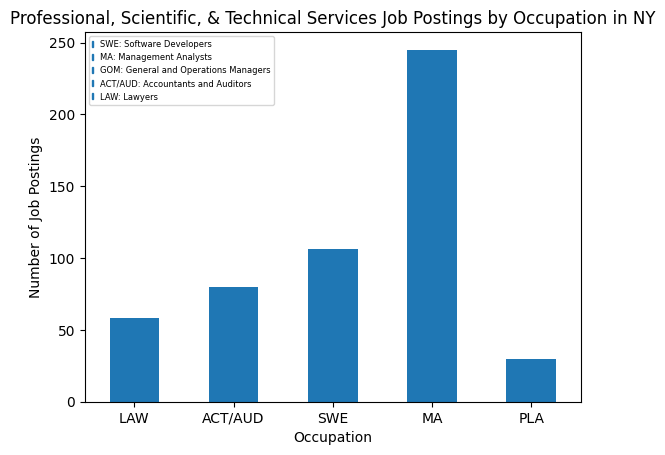

In [229]:
# Professional Scientific Technical Sector Bar Chart for NY
fi_barchart = pd.DataFrame({
    'Occupation': [
        "LAW",
        "ACT/AUD",
        "SWE",
        "MA",
        "PLA"
    ],
    'Job Postings': [
        ny_pst_occ_count.get("Lawyers", 0),
        ny_pst_occ_count.get("Accountants and Auditors", 0),
        ny_pst_occ_count.get("Software Developers", 0),
        ny_pst_occ_count.get("Management Analysts", 0),
        ny_pst_occ_count.get("Paralegals and Legal Assistants", 0)
    ]})

ax = fi_barchart.plot.bar(x='Occupation', y='Job Postings', rot=0)
plt.title("Professional, Scientific, & Technical Services Job Postings by Occupation in NY")
plt.xlabel("Occupation")
plt.ylabel("Number of Job Postings")

# legend
legend_labels = [
    mpatches.Patch(color='tab:blue', label="SWE: Software Developers"),
    mpatches.Patch(color='tab:blue', label="MA: Management Analysts"),
    mpatches.Patch(color='tab:blue', label="GOM: General and Operations Managers"),
    mpatches.Patch(color='tab:blue', label="ACT/AUD: Accountants and Auditors"),
    mpatches.Patch(color='tab:blue', label="LAW: Lawyers")
]
plt.legend(handles=legend_labels, loc='upper left', handlelength=0.1, fontsize=6)

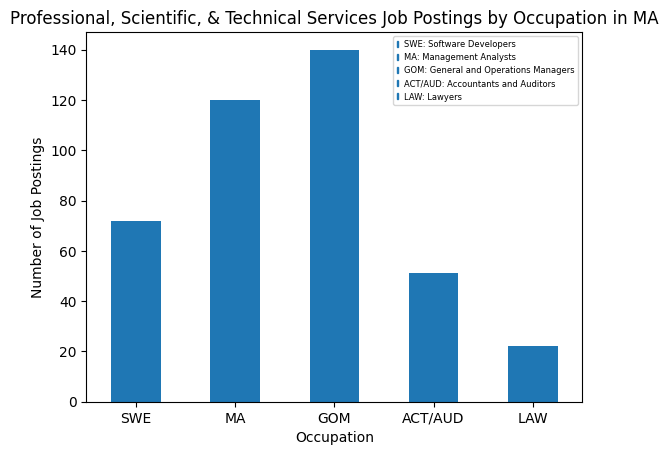

In [231]:
# Professional Scientific Technical Sector Bar Chart for MA
fi_barchart = pd.DataFrame({
    'Occupation': [
        "SWE",
        "MA",
        "GOM",
        "ACT/AUD",
        "LAW"
    ],
    'Job Postings': [
        ma_pst_occ_count.get("Software Developers", 0),
        ma_pst_occ_count.get("Management Analysts", 0),
        ma_pst_occ_count.get("General and Operations Managers", 0),
        ma_pst_occ_count.get("Accountants and Auditors", 0),
        ma_pst_occ_count.get("Lawyers", 0),
    ]})

ax = fi_barchart.plot.bar(x='Occupation', y='Job Postings', rot=0)
plt.title("Professional, Scientific, & Technical Services Job Postings by Occupation in MA")
plt.xlabel("Occupation")
plt.ylabel("Number of Job Postings")

# legend
legend_labels = [
    mpatches.Patch(color='tab:blue', label="SWE: Software Developers"),
    mpatches.Patch(color='tab:blue', label="MA: Management Analysts"),
    mpatches.Patch(color='tab:blue', label="GOM: General and Operations Managers"),
    mpatches.Patch(color='tab:blue', label="ACT/AUD: Accountants and Auditors"),
    mpatches.Patch(color='tab:blue', label="LAW: Lawyers")
]
plt.legend(handles=legend_labels, loc='upper right', handlelength=0.1, fontsize=6)

In [342]:
## Retail Trade Sector Merged Data for MA and NY
ma_rt_path = current_dir + ma_path + sector_paths[2] + "/"
ny_rt_path = current_dir + ny_path + sector_paths[2] + "/"

ma_rt_files = os.listdir(ma_rt_path)
ny_rt_files = os.listdir(ny_rt_path)

ma_rt_df = pd.DataFrame()
ny_rt_df = pd.DataFrame()

ma_rt_occ_count = {}
ny_rt_occ_count = {}
ma_rt_salary_disc = {"total": 0}
ny_rt_salary_disc = {"total": 0}
ma_rt_link_disc = {"total": 0}
ny_rt_link_disc = {"total": 0}

# merging data for all sector job postings based on state
for file in ma_rt_files:
    occ_code = file.split("-")[2]
    occupation = rt_occupation_codes.get(occ_code, "Unknown")
    data = pd.read_csv(ma_rt_path + "/" + file)
    if occupation in ma_rt_occ_count:
        ma_rt_occ_count[occupation] += len(data)
    else:
        ma_rt_occ_count[occupation] = len(data)
    ma_salary_df = data[["min_amount", "max_amount"]]
    ma_salary_disclosure_df = ma_salary_df.dropna()
    if occupation in ma_rt_salary_disc:
        ma_rt_salary_disc[occupation] += len(ma_salary_disclosure_df)
    else:
        ma_rt_salary_disc[occupation] = len(ma_salary_disclosure_df)
    ma_rt_salary_disc["total"] += len(ma_salary_disclosure_df)
    ma_rt_link_disc["total"] += len(data["job_url_direct"].dropna())
    ma_rt_df = pd.concat([ma_rt_df, data], ignore_index=True)

for file in ny_rt_files:
    occ_code = file.split("-")[2]
    occupation = rt_occupation_codes.get(occ_code, "Unknown")
    data = pd.read_csv(ny_rt_path + "/" + file)
    if occupation in ny_rt_occ_count:
        ny_rt_occ_count[occupation] += len(data)
    else:
        ny_rt_occ_count[occupation] = len(data)
    ny_salary_df = data[["min_amount", "max_amount"]]
    ny_salary_disclosure_df = ny_salary_df.dropna()
    if occupation in ny_rt_salary_disc:
        ny_rt_salary_disc[occupation] += len(ny_salary_disclosure_df)
    else:
        ny_rt_salary_disc[occupation] = len(ny_salary_disclosure_df)
    ny_rt_salary_disc["total"] += len(ny_salary_disclosure_df)
    ny_rt_link_disc["total"] += len(data["job_url_direct"].dropna())
    ny_rt_df = pd.concat([ny_rt_df, data], ignore_index=True)

ma_rt_df = ma_rt_df.drop(columns=['company_logo', 'skills', 'experience_range', 'company_rating', 'company_reviews_count', 'vacancy_count', 'work_from_home_type'])
ny_rt_df = ny_rt_df.drop(columns=['company_logo', 'skills', 'experience_range', 'company_rating', 'company_reviews_count', 'vacancy_count', 'work_from_home_type'])

In [234]:
print("MA RT Total: " + str(len(ma_rt_df)))
print("NY RT Total: " + str(len(ny_rt_df)))
print("MA RT LinkedIn: " + str(len(ma_rt_df[ma_rt_df["site"] == "linkedin"])))
print("MA RT Indeed: " + str(len(ma_rt_df[ma_rt_df["site"] == "indeed"])))
print("NY RT LinkedIn: " + str(len(ny_rt_df[ny_rt_df["site"] == "linkedin"])))
print("NY RT Indeed: " + str(len(ny_rt_df[ny_rt_df["site"] == "indeed"])))
print("MA RT Occupation Counts:" + str(ma_rt_occ_count))
print("NY RT Occupation Counts:" + str(ny_rt_occ_count))

MA RT Total: 496
NY RT Total: 680
MA RT LinkedIn: 242
MA RT Indeed: 254
NY RT LinkedIn: 416
NY RT Indeed: 264
MA RT Occupation Counts:{'Cashiers': 25, 'Customer Service Representatives': 91, 'First-Line Supervisors of Retail Sales Workers': 330, 'Retail Salespersons': 40, 'Stockers and Order Fillers': 10}
NY RT Occupation Counts:{'Cashiers': 47, 'First-Line Supervisors of Retail Sales Workers': 360, 'General and Operations Managers': 213, 'Retail Salespersons': 54, 'Stockers and Order Fillers': 6}


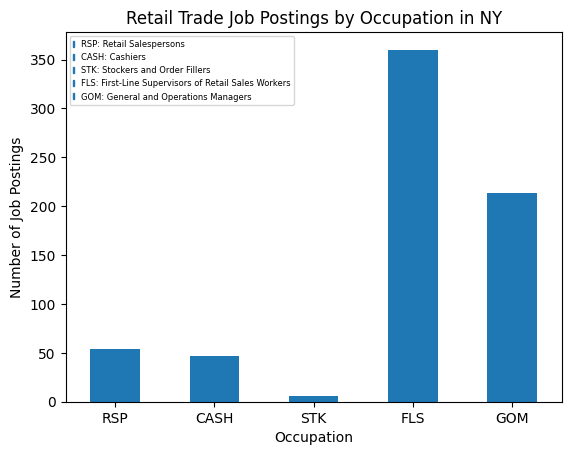

In [241]:
# Retail Trade Sector Bar Chart for NY
rt_barchart = pd.DataFrame({
    'Occupation': [
        "RSP",
        "CASH",
        "STK",
        "FLS",
        "GOM"
    ],
    'Job Postings': [
        ny_rt_occ_count.get("Retail Salespersons", 0),
        ny_rt_occ_count.get("Cashiers", 0),
        ny_rt_occ_count.get("Stockers and Order Fillers", 0),
        ny_rt_occ_count.get("First-Line Supervisors of Retail Sales Workers", 0),
        ny_rt_occ_count.get("General and Operations Managers", 0),
    ]})

ax = rt_barchart.plot.bar(x='Occupation', y='Job Postings', rot=0)
plt.title("Retail Trade Job Postings by Occupation in NY")
plt.xlabel("Occupation")
plt.ylabel("Number of Job Postings")

# legend
legend_labels = [
    mpatches.Patch(color='tab:blue', label="RSP: Retail Salespersons"),
    mpatches.Patch(color='tab:blue', label="CASH: Cashiers"),
    mpatches.Patch(color='tab:blue', label="STK: Stockers and Order Fillers"),
    mpatches.Patch(color='tab:blue', label="FLS: First-Line Supervisors of Retail Sales Workers"),
    mpatches.Patch(color='tab:blue', label="GOM: General and Operations Managers")
]
plt.legend(handles=legend_labels, loc='upper left', handlelength=0.1, fontsize=6)

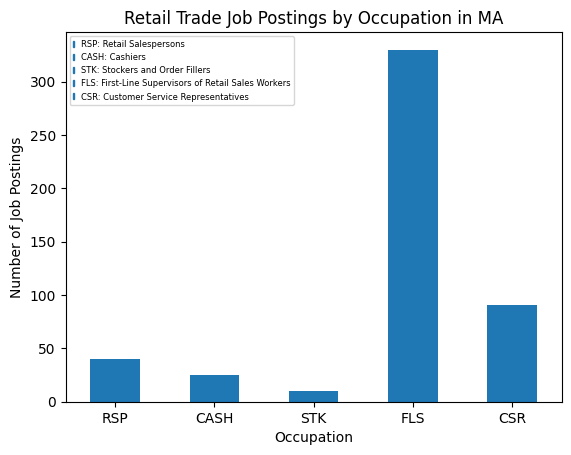

In [239]:
# Retail Trade Sector Bar Chart for MA
rt_barchart = pd.DataFrame({
    'Occupation': [
        "RSP",
        "CASH",
        "STK",
        "FLS",
        "CSR"
    ],
    'Job Postings': [
        ma_rt_occ_count.get("Retail Salespersons", 0),
        ma_rt_occ_count.get("Cashiers", 0),
        ma_rt_occ_count.get("Stockers and Order Fillers", 0),
        ma_rt_occ_count.get("First-Line Supervisors of Retail Sales Workers", 0),
        ma_rt_occ_count.get("Customer Service Representatives", 0),
    ]})

ax = rt_barchart.plot.bar(x='Occupation', y='Job Postings', rot=0)
plt.title("Retail Trade Job Postings by Occupation in MA")
plt.xlabel("Occupation")
plt.ylabel("Number of Job Postings")

# legend
legend_labels = [
    mpatches.Patch(color='tab:blue', label="RSP: Retail Salespersons"),
    mpatches.Patch(color='tab:blue', label="CASH: Cashiers"),
    mpatches.Patch(color='tab:blue', label="STK: Stockers and Order Fillers"),
    mpatches.Patch(color='tab:blue', label="FLS: First-Line Supervisors of Retail Sales Workers"),
    mpatches.Patch(color='tab:blue', label="CSR: Customer Service Representatives")
]
plt.legend(handles=legend_labels, loc='upper left', handlelength=0.1, fontsize=6)

In [355]:
## Creating merged datasets for MA and NY job postings across all sectors
# accessing files
ma_files = os.listdir(current_dir + ma_path)
ny_files = os.listdir(current_dir + ny_path)

ma_df = pd.DataFrame()
ny_df = pd.DataFrame()

# merging data for all sector job postings based on state
for sector in sector_paths:
    path = current_dir + ma_path + sector
    files_in_sector = os.listdir(current_dir + ma_path + sector)
    for file in files_in_sector:
        data = pd.read_csv(path + "/" + file)
        ma_df = pd.concat([ma_df, data], ignore_index=True)

for sector in sector_paths:
    path = current_dir + ny_path + sector
    files_in_sector = os.listdir(current_dir + ny_path + sector)
    for file in files_in_sector:
        data = pd.read_csv(path + "/" + file)
        ny_df = pd.concat([ny_df, data], ignore_index=True)

# drop unnecessary columns
ma_df = ma_df.drop(columns=['id', 'company_logo', 'skills', 'experience_range', 'company_rating', 'company_reviews_count', 'vacancy_count', 'work_from_home_type'])
ny_df = ny_df.drop(columns=['id', 'company_logo', 'skills', 'experience_range', 'company_rating', 'company_reviews_count', 'vacancy_count', 'work_from_home_type'])

print(len(ma_df))
print(len(ny_df))

1044
1634


In [356]:
# Combining data for all sectors for each state
full_df = pd.concat([ma_df, ny_df], ignore_index=True)
full_fi_df = pd.concat([ma_fi_df, ny_fi_df], ignore_index=True)
full_pst_df = pd.concat([ma_pst_df, ny_pst_df], ignore_index=True)
full_rt_df = pd.concat([ma_rt_df, ny_rt_df], ignore_index=True)

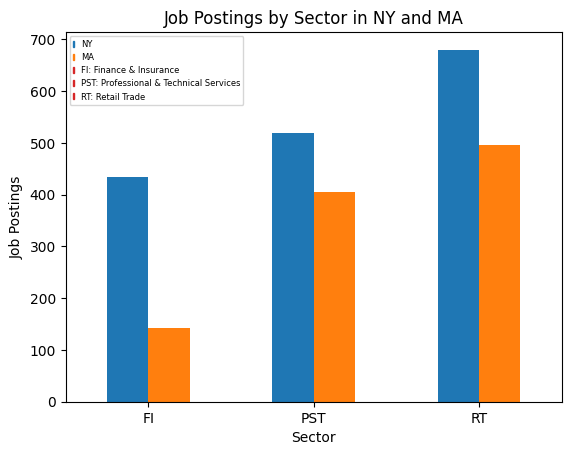

In [359]:
## Merged Occupational Distribution Bar Chart for NY and MA
ny_bars = [
    len(ny_fi_df),
    len(ny_pst_df),
    len(ny_rt_df)
]
ma_bars = [
    len(ma_fi_df),
    len(ma_pst_df),
    len(ma_rt_df)
]
rt_barchart = pd.DataFrame({
    'Sector': [
        "FI",
        "PST",
        "RT",
    ],
    'Job Postings NY': ny_bars,
    'Job Postings MA': ma_bars
    })

ax = rt_barchart.plot.bar(x='Sector', y=['Job Postings NY', 'Job Postings MA'], rot=0)
plt.title("Job Postings by Sector in NY and MA")
plt.xlabel("Sector")
plt.ylabel("Job Postings")

# legend
legend_labels = [
    mpatches.Patch(color='tab:blue', label="NY"),
    mpatches.Patch(color='tab:orange', label="MA"),
    mpatches.Patch(color='tab:red', label="FI: Finance & Insurance"),
    mpatches.Patch(color='tab:red', label="PST: Professional & Technical Services"),
    mpatches.Patch(color='tab:red', label="RT: Retail Trade"),
]
plt.legend(handles=legend_labels, loc='upper left', handlelength=0.1, fontsize=6)

In [375]:
## Merged Occupational Distribution Bar Chart for NY and MA
rt_barchart = pd.DataFrame({
    'Sector': ["FI", "FI", "PST", "PST", "RT", "RT"],
    'Platform': ["LinkedIn", "Indeed", "LinkedIn", "Indeed", "LinkedIn", "Indeed"],
    'NY': [
        len(ny_fi_df[ny_fi_df["site"] == "linkedin"]),
        len(ny_fi_df[ny_fi_df["site"] == "indeed"]),
        len(ny_pst_df[ny_pst_df["site"] == "linkedin"]),
        len(ny_pst_df[ny_pst_df["site"] == "indeed"]),
        len(ny_rt_df[ny_rt_df["site"] == "linkedin"]),
        len(ny_rt_df[ny_rt_df["site"] == "indeed"])
    ],
    'MA': [
        len(ma_fi_df[ma_fi_df["site"] == "linkedin"]),
        len(ma_fi_df[ma_fi_df["site"] == "indeed"]),
        len(ma_pst_df[ma_pst_df["site"] == "linkedin"]),
        len(ma_pst_df[ma_pst_df["site"] == "indeed"]),
        len(ma_rt_df[ma_rt_df["site"] == "linkedin"]),
        len(ma_rt_df[ma_rt_df["site"] == "indeed"])    
    ]
    })

ax = rt_barchart.plot.bar(subplots=True, x='Sector/Platform', 
    y=['Job Postings FI LinkedIn', 'Job Postings FI Indeed', 
       'Job Postings PST LinkedIn', 'Job Postings PST Indeed',
       'Job Postings RT LinkedIn', 'Job Postings RT Indeed'], rot=0)
plt.title("Job Postings by Sector and Platform in NY and MA")
plt.xlabel("Sector/Platform")
plt.ylabel("Job Postings")

# legend
legend_labels = [
    mpatches.Patch(color='tab:blue', label="NY Linkedin"),
    mpatches.Patch(color='tab:orange', label="MA Linkedin"),
    mpatches.Patch(color='tab:green', label="NY Indeed"),
    mpatches.Patch(color='tab:purple', label="MA Indeed"),
    mpatches.Patch(color='tab:red', label="FI: Finance & Insurance"),
    mpatches.Patch(color='tab:red', label="PST: Professional & Technical Services"),
    mpatches.Patch(color='tab:red', label="RT: Retail Trade"),
]
plt.legend(handles=legend_labels, loc='upper left', handlelength=0.1, fontsize=6)

KeyError: 'Sector/Platform'

In [269]:
## Salary Disclosure 
ma_salary_df = ma_df[["min_amount", "max_amount"]]
ma_salary_disclosure_df = ma_salary_df.dropna()
print("MA Salary Disclosure Total: " + str(len(ma_salary_disclosure_df)))
print("MA Salary Disclosure Rate: " + str(len(ma_salary_disclosure_df) / len(ma_salary_df)))

ny_salary_df = ny_df[["min_amount", "max_amount"]]
ny_salary_disclosure_df = ny_salary_df.dropna()
print("NY Salary Disclosure Total: " + str(len(ny_salary_disclosure_df)))
print("NY Salary Disclosure Rate: " + str(len(ny_salary_disclosure_df) / len(ny_salary_df)))

MA Salary Disclosure Total: 335
MA Salary Disclosure Rate: 0.32088122605363983
NY Salary Disclosure Total: 658
NY Salary Disclosure Rate: 0.40269277845777235


In [294]:
## MA Salary Disclosure by Sector
print(ma_fi_salary_disc)
print(ma_pst_salary_disc)
print(ma_rt_salary_disc)

{'total': 26, 'Finance and Investment Analysts': 11, 'Financial Managers': 3, 'Securities, Commodities, and Financial Services': 5, 'Insurance Sales Agents': 1, 'Personal Financial Advisors': 6}
{'total': 102, 'Accountants and Auditors': 8, 'Management Analysts': 31, 'General and Operations Managers': 14, 'Lawyers': 4, 'Software Developers': 45}
{'total': 207, 'Cashiers': 1, 'Customer Service Representatives': 13, 'First-Line Supervisors of Retail Sales Workers': 189, 'Retail Salespersons': 0, 'Stockers and Order Fillers': 4}


In [295]:
## NY Salary Disclosure by Sector
print(ny_fi_salary_disc)
print(ny_pst_salary_disc)
print(ny_rt_salary_disc)

{'total': 212, 'Customer Service Representative': 21, 'Finance and Investment Analysts': 103, 'Financial Managers': 25, 'Securities, Commodities, and Financial Services': 43, 'Personal Financial Advisors': 20}
{'total': 204, 'Accountants and Auditors': 9, 'Management Analysts': 126, 'Lawyers': 19, 'Paralegals and Legal Assistants': 2, 'Software Developers': 48}
{'total': 242, 'Cashiers': 9, 'First-Line Supervisors of Retail Sales Workers': 196, 'General and Operations Managers': 33, 'Retail Salespersons': 1, 'Stockers and Order Fillers': 3}


In [324]:
# drop unnecessary columns for salary disclosure analysis
full_salary_df = full_df[["site", "min_amount", "max_amount"]]
full_salary_disclosure_df = full_salary_df.dropna()

full_fi_salary_df = full_fi_df[["site", "min_amount", "max_amount"]]
full_fi_salary_disclosure_df = full_fi_salary_df.dropna()

full_pst_salary_df = full_pst_df[["site", "min_amount", "max_amount"]]
full_pst_salary_disclosure_df = full_pst_salary_df.dropna()

full_rt_salary_df = full_rt_df[["min_amount", "max_amount"]]
full_rt_salary_disclosure_df = full_rt_salary_df.dropna()

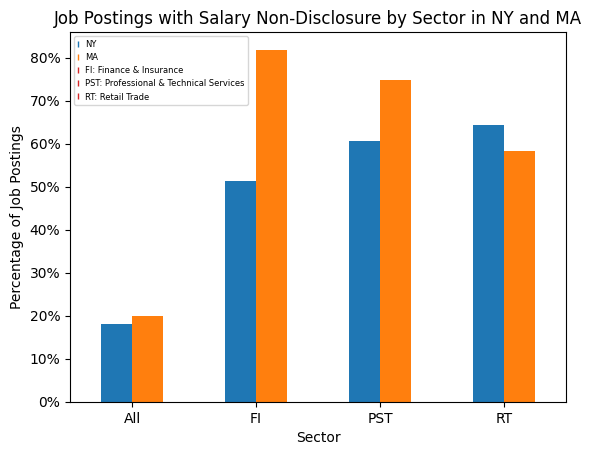

In [329]:
## Salary Non-Disclosure by Sector and State
ny_bars = [
    len(ny_salary_disclosure_df) / len(ny_salary_df) * 100 if len(ny_salary_df) > 0 else 0,
    (len(ny_fi_df) - ny_fi_salary_disc.get("total", 0))/len(ny_fi_df) * 100 if len(ny_fi_df) > 0 else 0,
    (len(ny_pst_df) - ny_pst_salary_disc.get("total", 0))/len(ny_pst_df) * 100 if len(ny_pst_df) > 0 else 0,
    (len(ny_rt_df) - ny_rt_salary_disc.get("total", 0))/len(ny_rt_df) * 100 if len(ny_rt_df) > 0 else 0
]
ma_bars = [
    len(ma_salary_disclosure_df) / len(ma_salary_df) * 100 if len(ma_salary_df) > 0 else 0,
    (len(ma_fi_df) - ma_fi_salary_disc.get("total", 0))/len(ma_fi_df) * 100 if len(ma_fi_df) > 0 else 0,
    (len(ma_pst_df) - ma_pst_salary_disc.get("total", 0))/len(ma_pst_df) * 100 if len(ma_pst_df) > 0 else 0,
    (len(ma_rt_df) - ma_rt_salary_disc.get("total", 0))/len(ma_rt_df) * 100 if len(ma_rt_df) > 0 else 0
]
rt_barchart = pd.DataFrame({
    'Sector': [
        "All",
        "FI",
        "PST",
        "RT",
    ],
    'Job Postings NY': ny_bars,
    'Job Postings MA': ma_bars
    })

ax = rt_barchart.plot.bar(x='Sector', y=['Job Postings NY', 'Job Postings MA'], rot=0)
plt.title("Job Postings with Salary Non-Disclosure by Sector in NY and MA")
plt.xlabel("Sector")
plt.ylabel("Percentage of Job Postings")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

# legend
legend_labels = [
    mpatches.Patch(color='tab:blue', label="NY"),
    mpatches.Patch(color='tab:orange', label="MA"),
    mpatches.Patch(color='tab:red', label="FI: Finance & Insurance"),
    mpatches.Patch(color='tab:red', label="PST: Professional & Technical Services"),
    mpatches.Patch(color='tab:red', label="RT: Retail Trade"),
]
plt.legend(handles=legend_labels, loc='upper left', handlelength=0.1, fontsize=6)

C:\Users\maggi\AppData\Local\Temp\ipykernel_32700\1851866360.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  (len(full_df[full_df["site"] == "linkedin"]) - len(full_salary_disclosure_df[full_df["site"] == "linkedin"]))/len(full_df[full_df["site"] == "linkedin"]) * 100 if len(full_df[full_df["site"] == "linkedin"]) > 0 else 0,
C:\Users\maggi\AppData\Local\Temp\ipykernel_32700\1851866360.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  (len(full_fi_df[full_fi_df["site"] == "linkedin"]) - len(full_fi_salary_disclosure_df[full_fi_df["site"] == "linkedin"]))/len(full_fi_df[full_fi_df["site"] == "linkedin"]) * 100 if len(full_fi_df[full_fi_df["site"] == "linkedin"]) > 0 else 0,
C:\Users\maggi\AppData\Local\Temp\ipykernel_32700\1851866360.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  (len(full_pst_df[full_pst_df["site"] == "linkedin"]) - len(full_pst_salary_disclosure_df[full_pst_df["s

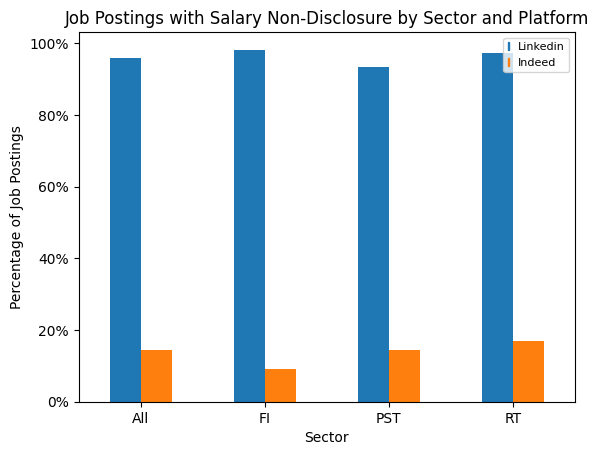

In [331]:
## Salary Non-Disclosure by Platform and Sector
linkedin_bars = [
    (len(full_df[full_df["site"] == "linkedin"]) - len(full_salary_disclosure_df[full_df["site"] == "linkedin"]))/len(full_df[full_df["site"] == "linkedin"]) * 100 if len(full_df[full_df["site"] == "linkedin"]) > 0 else 0,
    (len(full_fi_df[full_fi_df["site"] == "linkedin"]) - len(full_fi_salary_disclosure_df[full_fi_df["site"] == "linkedin"]))/len(full_fi_df[full_fi_df["site"] == "linkedin"]) * 100 if len(full_fi_df[full_fi_df["site"] == "linkedin"]) > 0 else 0,
    (len(full_pst_df[full_pst_df["site"] == "linkedin"]) - len(full_pst_salary_disclosure_df[full_pst_df["site"] == "linkedin"]))/len(full_pst_df[full_pst_df["site"] == "linkedin"]) * 100 if len(full_pst_df[full_pst_df["site"] == "linkedin"]) > 0 else 0,
    (len(full_rt_df[full_rt_df["site"] == "linkedin"]) - len(full_rt_salary_disclosure_df[full_rt_df["site"] == "linkedin"]))/len(full_rt_df[full_rt_df["site"] == "linkedin"]) * 100 if len(full_rt_df[full_rt_df["site"] == "linkedin"]) > 0 else 0
]
indeed_bars = [
    (len(full_df[full_df["site"] == "indeed"]) - len(full_salary_disclosure_df[full_salary_disclosure_df["site"] == "indeed"]))/len(full_df[full_df["site"] == "indeed"]) * 100 if len(full_df[full_df["site"] == "indeed"]) > 0 else 0,
    (len(full_fi_df[full_fi_df["site"] == "indeed"]) - len(full_fi_salary_disclosure_df[full_fi_df["site"] == "indeed"]))/len(full_fi_df[full_fi_df["site"] == "indeed"]) * 100 if len(full_fi_df[full_fi_df["site"] == "indeed"]) > 0 else 0,
    (len(full_pst_df[full_pst_df["site"] == "indeed"]) - len(full_pst_salary_disclosure_df[full_pst_df["site"] == "indeed"]))/len(full_pst_df[full_pst_df["site"] == "indeed"]) * 100 if len(full_pst_df[full_pst_df["site"] == "indeed"]) > 0 else 0,
    (len(full_rt_df[full_rt_df["site"] == "indeed"]) - len(full_rt_salary_disclosure_df[full_rt_df["site"] == "indeed"]))/len(full_rt_df[full_rt_df["site"] == "indeed"]) * 100 if len(full_rt_df[full_rt_df["site"] == "indeed"]) > 0 else 0
]
rt_barchart = pd.DataFrame({
    'Sector': [
        "All",
        "FI",
        "PST",
        "RT",
    ],
    'Job Postings NY': linkedin_bars,
    'Job Postings MA': indeed_bars
    })

ax = rt_barchart.plot.bar(x='Sector', y=['Job Postings NY', 'Job Postings MA'], rot=0)
plt.title("Job Postings with Salary Non-Disclosure by Sector and Platform")
plt.xlabel("Sector")
plt.ylabel("Percentage of Job Postings")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

# legend
legend_labels = [
    mpatches.Patch(color='tab:blue', label="Linkedin"),
    mpatches.Patch(color='tab:orange', label="Indeed"),
]

plt.legend(handles=legend_labels, loc='upper right', handlelength=0.1, fontsize=8)

In [346]:
## Valid URL By State
ma_link_df = ma_df[["site", "job_url_direct"]]
ma_link_disclosure_df = ma_link_df.dropna()
print("MA Link Total: " + str(len(ma_link_disclosure_df)))
print("MA Link Rate: " + str(len(ma_link_disclosure_df) / len(ma_link_df)))

ny_link_df = ny_df[["site", "job_url_direct"]]
ny_link_disclosure_df = ny_link_df.dropna()
print("NY Link Total: " + str(len(ny_link_disclosure_df)))
print("NY Link Rate: " + str(len(ny_link_disclosure_df) / len(ny_link_df)))

MA Link Total: 619
MA Link Rate: 0.592911877394636
NY Link Total: 1009
NY Link Rate: 0.6175030599755202


In [347]:
# drop unnecessary columns for salary disclosure analysis
full_link_df = full_df[["site", "job_url_direct"]]
full_link_disclosure_df = full_link_df.dropna()

full_fi_link_df = full_fi_df[["site", "job_url_direct"]]
full_fi_link_disclosure_df = full_fi_link_df.dropna()

full_pst_link_df = full_pst_df[["site", "job_url_direct"]]
full_pst_link_disclosure_df = full_pst_link_df.dropna()

full_rt_link_df = full_rt_df[["site", "job_url_direct"]]
full_rt_link_disclosure_df = full_rt_link_df.dropna()

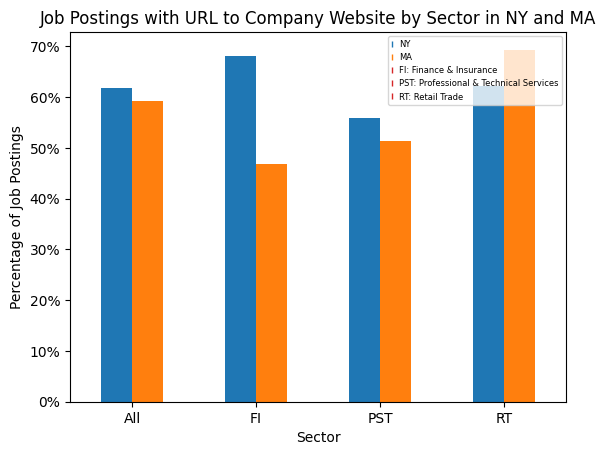

In [352]:
## Career Page Validation Rate by Sector and State
ny_bars = [
    len(ny_link_disclosure_df) / len(ny_link_df) * 100 if len(ny_link_df) > 0 else 0,
    (ny_fi_link_disc.get("total", 0))/len(ny_fi_df) * 100 if len(ny_fi_df) > 0 else 0,
    (ny_pst_link_disc.get("total", 0))/len(ny_pst_df) * 100 if len(ny_pst_df) > 0 else 0,
    (ny_rt_link_disc.get("total", 0))/len(ny_rt_df) * 100 if len(ny_rt_df) > 0 else 0
]
ma_bars = [
    len(ma_link_disclosure_df) / len(ma_link_df) * 100 if len(ma_link_df) > 0 else 0,
    (ma_fi_link_disc.get("total", 0))/len(ma_fi_df) * 100 if len(ma_fi_df) > 0 else 0,
    (ma_pst_link_disc.get("total", 0))/len(ma_pst_df) * 100 if len(ma_pst_df) > 0 else 0,
    (ma_rt_link_disc.get("total", 0))/len(ma_rt_df) * 100 if len(ma_rt_df) > 0 else 0
]
rt_barchart = pd.DataFrame({
    'Sector': [
        "All",
        "FI",
        "PST",
        "RT",
    ],
    'Job Postings NY': ny_bars,
    'Job Postings MA': ma_bars
    })

ax = rt_barchart.plot.bar(x='Sector', y=['Job Postings NY', 'Job Postings MA'], rot=0)
plt.title("Job Postings with URL to Company Website by Sector in NY and MA")
plt.xlabel("Sector")
plt.ylabel("Percentage of Job Postings")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

# legend
legend_labels = [
    mpatches.Patch(color='tab:blue', label="NY"),
    mpatches.Patch(color='tab:orange', label="MA"),
    mpatches.Patch(color='tab:red', label="FI: Finance & Insurance"),
    mpatches.Patch(color='tab:red', label="PST: Professional & Technical Services"),
    mpatches.Patch(color='tab:red', label="RT: Retail Trade"),
]
plt.legend(handles=legend_labels, loc='upper right', handlelength=0.1, fontsize=6)

C:\Users\maggi\AppData\Local\Temp\ipykernel_32700\336263703.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  (len(full_link_disclosure_df[full_df["site"] == "linkedin"]))/len(full_df[full_df["site"] == "linkedin"]) * 100 if len(full_df[full_df["site"] == "linkedin"]) > 0 else 0,
C:\Users\maggi\AppData\Local\Temp\ipykernel_32700\336263703.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  (len(full_fi_link_disclosure_df[full_fi_df["site"] == "linkedin"]))/len(full_fi_df[full_fi_df["site"] == "linkedin"]) * 100 if len(full_fi_df[full_fi_df["site"] == "linkedin"]) > 0 else 0,
C:\Users\maggi\AppData\Local\Temp\ipykernel_32700\336263703.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  (len(full_pst_link_disclosure_df[full_pst_df["site"] == "linkedin"]))/len(full_pst_df[full_pst_df["site"] == "linkedin"]) * 100 if len(full_pst_df[full_pst_df["site"] == "linkedin"]) > 0 else 0,
C:\Users\magg

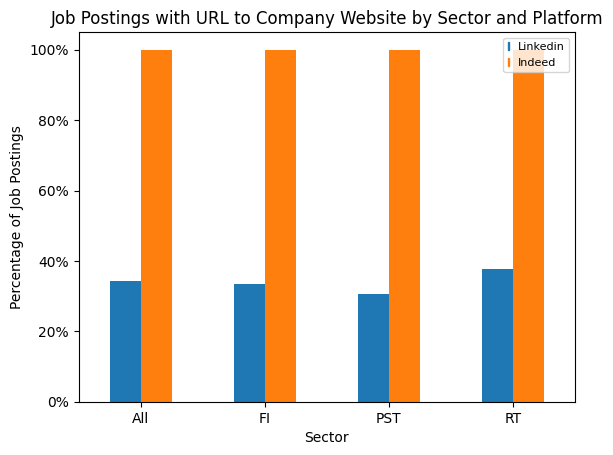

In [353]:
## Career Page Validation Rate by Platform and Sector
linkedin_bars = [
    (len(full_link_disclosure_df[full_df["site"] == "linkedin"]))/len(full_df[full_df["site"] == "linkedin"]) * 100 if len(full_df[full_df["site"] == "linkedin"]) > 0 else 0,
    (len(full_fi_link_disclosure_df[full_fi_df["site"] == "linkedin"]))/len(full_fi_df[full_fi_df["site"] == "linkedin"]) * 100 if len(full_fi_df[full_fi_df["site"] == "linkedin"]) > 0 else 0,
    (len(full_pst_link_disclosure_df[full_pst_df["site"] == "linkedin"]))/len(full_pst_df[full_pst_df["site"] == "linkedin"]) * 100 if len(full_pst_df[full_pst_df["site"] == "linkedin"]) > 0 else 0,
    (len(full_rt_link_disclosure_df[full_rt_df["site"] == "linkedin"]))/len(full_rt_df[full_rt_df["site"] == "linkedin"]) * 100 if len(full_rt_df[full_rt_df["site"] == "linkedin"]) > 0 else 0
]
indeed_bars = [
    (len(full_link_disclosure_df[full_link_disclosure_df["site"] == "indeed"]))/len(full_df[full_df["site"] == "indeed"]) * 100 if len(full_df[full_df["site"] == "indeed"]) > 0 else 0,
    (len(full_fi_link_disclosure_df[full_fi_df["site"] == "indeed"]))/len(full_fi_df[full_fi_df["site"] == "indeed"]) * 100 if len(full_fi_df[full_fi_df["site"] == "indeed"]) > 0 else 0,
    (len(full_pst_link_disclosure_df[full_pst_df["site"] == "indeed"]))/len(full_pst_df[full_pst_df["site"] == "indeed"]) * 100 if len(full_pst_df[full_pst_df["site"] == "indeed"]) > 0 else 0,
    (len(full_rt_link_disclosure_df[full_rt_df["site"] == "indeed"]))/len(full_rt_df[full_rt_df["site"] == "indeed"]) * 100 if len(full_rt_df[full_rt_df["site"] == "indeed"]) > 0 else 0
]
rt_barchart = pd.DataFrame({
    'Sector': [
        "All",
        "FI",
        "PST",
        "RT",
    ],
    'Job Postings NY': linkedin_bars,
    'Job Postings MA': indeed_bars
    })

ax = rt_barchart.plot.bar(x='Sector', y=['Job Postings NY', 'Job Postings MA'], rot=0)
plt.title("Job Postings with URL to Company Website by Sector and Platform")
plt.xlabel("Sector")
plt.ylabel("Percentage of Job Postings")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

# legend
legend_labels = [
    mpatches.Patch(color='tab:blue', label="Linkedin"),
    mpatches.Patch(color='tab:orange', label="Indeed"),
]

plt.legend(handles=legend_labels, loc='upper right', handlelength=0.1, fontsize=8)

In [332]:
ma_df.head(2)

,site,job_url,job_url_direct,title,company,location,date_posted,job_type,salary_source,interval,...,listing_type,emails,description,company_industry,company_url,company_url_direct,company_addresses,company_num_employees,company_revenue,company_description
0,indeed,https://www.indeed.com/viewjob?jk=6bf8abd77e61...,https://statestreet.wd1.myworkdayjobs.com/en-U...,"GPD - Check Reconcilement Specialist, 6 Months...",State Street,"Quincy, MA, US",2026-02-23,fulltime,direct_data,yearly,...,NaN,NaN,"Working under the general supervision, the inc...",NaN,https://www.indeed.com/cmp/State-Street-1,http://www.statestreet.com,"Boston, MA","10,000+",more than $10B (USD),A State Street career means a chance to grow y...
1,indeed,https://www.indeed.com/viewjob?jk=6ecf75d4a781...,https://workforcenow.adp.com/mascsr/default/md...,Financial Data Analyst,New England Life Care,"Canton, MA, US",2026-02-23,fulltime,direct_data,yearly,...,NaN,NaN,NELC is one of the fastest growing home infusi...,Health Care,https://www.indeed.com/cmp/New-England-Life-Care,https://www.nelifecare.org/,"600 Southborough Drive, South Portland, ME 04106",201 to 500,$25M to $100M (USD),New England Life Care (NELC) is the preeminent...


In [103]:
from jobspy import scrape_jobs
jobs = scrape_jobs(
    site_name=["indeed", "linkedin"], # "glassdoor", "bayt", "naukri", "bdjobs"
    search_term="department manager",
    location="New York, NY",
    results_wanted=100,
    hours_old=24,
    country_indeed='USA',
    
    linkedin_fetch_description=True, # gets more info such as description, direct job url (slower)
    # proxies=["208.195.175.46:65095", "208.195.175.45:65095", "localhost"],
)
print(f"Found {len(jobs)} jobs")


Found 160 jobs


In [105]:
import csv
jobs.to_csv("NY-RT-DM-02.23.36.csv", quoting=csv.QUOTE_ALL, escapechar="\\", index=False) # to_excel
df = pd.read_csv("NY-RT-DM-02.23.36.csv") # to_excel
print(df.columns.tolist())
print(df.shape)
print(df[['title', 'company', 'location', 'site', 'date_posted']].head(10))


['id', 'site', 'job_url', 'job_url_direct', 'title', 'company', 'location', 'date_posted', 'job_type', 'salary_source', 'interval', 'min_amount', 'max_amount', 'currency', 'is_remote', 'job_level', 'job_function', 'listing_type', 'emails', 'description', 'company_industry', 'company_url', 'company_logo', 'company_url_direct', 'company_addresses', 'company_num_employees', 'company_revenue', 'company_description', 'skills', 'experience_range', 'company_rating', 'company_reviews_count', 'vacancy_count', 'work_from_home_type']
(160, 34)
                                         title                     company  \
0                 HRBP Manager, IT – Hybrid NY      Healthfirst (New York)   
1                   Assistant Property Manager  Crosstown Management Corp.   
2  Sales & Marketing Support Assistant Manager  Liberty Moving and Storage   
3        Retail sales person-lingerie boutique             myself lingerie   
4                                Sales Manager         proof. Pest Cont

In [99]:
from jobspy import scrape_jobs
jobs = scrape_jobs(
    site_name=["indeed", "linkedin"], # "glassdoor", "bayt", "naukri", "bdjobs"
    search_term="department manager",
    location="Boston, MA",
    results_wanted=100,
    hours_old=24,
    country_indeed='USA',
    
    linkedin_fetch_description=True, # gets more info such as description, direct job url (slower)
    # proxies=["208.195.175.46:65095", "208.195.175.45:65095", "localhost"],
)
print(f"Found {len(jobs)} jobs")


Found 140 jobs


In [100]:
import csv
jobs.to_csv("MA-RT-DM-02.23.36.csv", quoting=csv.QUOTE_ALL, escapechar="\\", index=False) # to_excel
df = pd.read_csv("MA-RT-DM-02.23.36.csv") # to_excel
print(df.columns.tolist())
print(df.shape)
print(df[['title', 'company', 'location', 'site', 'date_posted']].head(10))


['id', 'site', 'job_url', 'job_url_direct', 'title', 'company', 'location', 'date_posted', 'job_type', 'salary_source', 'interval', 'min_amount', 'max_amount', 'currency', 'is_remote', 'job_level', 'job_function', 'listing_type', 'emails', 'description', 'company_industry', 'company_url', 'company_logo', 'company_url_direct', 'company_addresses', 'company_num_employees', 'company_revenue', 'company_description', 'skills', 'experience_range', 'company_rating', 'company_reviews_count', 'vacancy_count', 'work_from_home_type']
(140, 34)
                              title  \
0                   Account Manager   
1           Regional Safety Manager   
2           Regional Safety Manager   
3                   RN Unit Manager   
4            Trade Planning Manager   
5    Retail Sales and Store Support   
6       Assistant Front-End Manager   
7  Hospitality & Operations Manager   
8        Restaurant General Manager   
9         Assistant General Manager   

                               

In [70]:
df

,id,site,job_url,job_url_direct,title,company,location,date_posted,job_type,salary_source,...,company_addresses,company_num_employees,company_revenue,company_description,skills,experience_range,company_rating,company_reviews_count,vacancy_count,work_from_home_type
0,in-ab6919c45a88f209,indeed,https://www.indeed.com/viewjob?jk=ab6919c45a88...,https://careers.iwgplc.com/jobs/vacancy/enterp...,Enterprise Sales Manager (ESM),International Workplace Group,"East Rutherford, NJ, US",2026-02-23,fulltime,NaN,...,Zug,"5,001 to 10,000",Decline to state,"IWG plc, is the global operator of leading wor...",NaN,NaN,NaN,NaN,NaN,NaN
1,in-694c7c20de30d868,indeed,https://www.indeed.com/viewjob?jk=694c7c20de30...,https://roberthalf.wd1.myworkdayjobs.com/en-US...,New York City Business Performance Improvement...,Protiviti,"New York, NY, US",2026-02-23,"fulltime, internship",direct_data,...,"Menlo Park, CA","5,001 to 10,000",$1B to $5B (USD),Protiviti is a global consulting firm that pro...,NaN,NaN,NaN,NaN,NaN,NaN
2,in-16f4ca2e01f78118,indeed,https://www.indeed.com/viewjob?jk=16f4ca2e01f7...,https://roberthalf.wd1.myworkdayjobs.com/en-US...,New York Technology Consulting Intern - 2027,Protiviti,"New York, NY, US",2026-02-23,"fulltime, internship",direct_data,...,"Menlo Park, CA","5,001 to 10,000",$1B to $5B (USD),Protiviti is a global consulting firm that pro...,NaN,NaN,NaN,NaN,NaN,NaN
3,in-21d9b1071bd5f4e8,indeed,https://www.indeed.com/viewjob?jk=21d9b1071bd5...,https://roberthalf.wd1.myworkdayjobs.com/en-US...,"New York Legal, Risk and Compliance Intern - 2027",Protiviti,"New York, NY, US",2026-02-23,"fulltime, internship",direct_data,...,"Menlo Park, CA","5,001 to 10,000",$1B to $5B (USD),Protiviti is a global consulting firm that pro...,NaN,NaN,NaN,NaN,NaN,NaN
4,in-457088720daf1955,indeed,https://www.indeed.com/viewjob?jk=457088720daf...,https://JPMorganChase.contacthr.com/151154286,Business Modeling - Applied AI Modeling Lead (VP),JPMorganChase,"New York, NY, US",2026-02-23,fulltime,direct_data,...,"New York, NY","10,000+",more than $10B (USD),"Headquartered in New York City, JPMorgan Chase...",NaN,NaN,NaN,NaN,NaN,NaN
5,in-09a585fbfd402d05,indeed,https://www.indeed.com/viewjob?jk=09a585fbfd40...,https://jsv3.recruitics.com/redirect?rx_cid=13...,"Retail Cosmetics Sales Associate - YSL Beaute,...",Macy's,"Paramus, NJ, US",2026-02-22,parttime,direct_data,...,"New York, NY","10,000+",more than $10B (USD),"Macy’s, Inc., one of America’s most enduring, ...",NaN,NaN,NaN,NaN,NaN,NaN
6,in-9c038afe5b43f49e,indeed,https://www.indeed.com/viewjob?jk=9c038afe5b43...,https://jsv3.recruitics.com/redirect?rx_cid=13...,"Retail Cosmetics Sales Associate - YSL Beaute,...",Macy's,"Garden City, NY, US",2026-02-22,parttime,direct_data,...,"New York, NY","10,000+",more than $10B (USD),"Macy’s, Inc., one of America’s most enduring, ...",NaN,NaN,NaN,NaN,NaN,NaN
7,in-b2b6abad736f0dea,indeed,https://www.indeed.com/viewjob?jk=b2b6abad736f...,https://jsv3.recruitics.com/redirect?rx_cid=13...,Retail Cosmetics Sales Associate - Dior Beaute...,Macy's,"Flushing, NY, US",2026-02-22,fulltime,direct_data,...,"New York, NY","10,000+",more than $10B (USD),"Macy’s, Inc., one of America’s most enduring, ...",NaN,NaN,NaN,NaN,NaN,NaN
8,in-149c6d03a4c2953b,indeed,https://www.indeed.com/viewjob?jk=149c6d03a4c2...,https://jsv3.recruitics.com/redirect?rx_cid=13...,Retail Cosmetics Sales Counter Manager - Estee...,Macy's,"Flushing, NY, US",2026-02-22,fulltime,direct_data,...,"New York, NY","10,000+",more than $10B (USD),"Macy’s, Inc., one of America’s most enduring, ...",NaN,NaN,NaN,NaN,NaN,NaN
9,in-75a909161ab77a2e,indeed,https://www.indeed.com/viewjob?jk=75a909161ab7...,https://jsv3.recruitics.com/redirect?rx_cid=13...,"Retail Cosmetics Sales Associate - Clarins, Wa...",Macy's,"Huntington Station, NY, US",2026-02-22,parttime,direct_data,...,"New York, NY","10,000+",more than $10B (USD),"Macy’s, Inc., one of America’s most enduring, ...",NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
s = pd.Series(df["site"]).reset_index()
print(s.value_counts)
print((s["site"] == "linkedin").sum())

<bound method DataFrame.value_counts of     index      site
0       0    indeed
1       1    indeed
2       2    indeed
3       3    indeed
4       4    indeed
5       5  linkedin
6       6  linkedin
7       7  linkedin
8       8  linkedin
9       9  linkedin
10     10  linkedin
11     11  linkedin
12     12  linkedin
13     13  linkedin
14     14  linkedin
15     15  linkedin
16     16  linkedin
17     17  linkedin
18     18  linkedin
19     19  linkedin
20     20  linkedin
21     21  linkedin
22     22  linkedin
23     23  linkedin
24     24  linkedin
25     25  linkedin
26     26  linkedin
27     27  linkedin
28     28  linkedin>
24
